In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 

# set cosmology (for mdpl2)
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h

import halotools.sim_manager as sim_manager
import halotools.mock_observables as mock_observables

from compact.velocities.pw_moments import *
from compact.velocities.moments import *
from compact.catalog.accumulate import *
from compact.catalog.bin import *
from compact.streaming import *
from compact.tpcf import *
from compact.plot import *
from compact.model import *

from scipy.interpolate import UnivariateSpline

# reload project when changes are made
%load_ext autoreload
%autoreload 2

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

import os
import warnings
warnings.filterwarnings('ignore')

import psutil
psutil.Process().nice(10)


from scipy.optimize import curve_fit

In [52]:
from compact.config import Config
from compact.predictions import *

cfg = Config()
#cfg.r = np.arange(20.0, 132.0 + 4.0, 4.0)
model = CompactStreamingModel(redshift=0.5, config=cfg)

theta = np.array([0.5, 0.3, 0.02237, 0.12, 0.6777, 2.1e-9])
xi = np.stack(model.predict(theta, ells=(0, 2, 4)))
print(xi.shape, np.isfinite(xi).all())

(3, 156) True


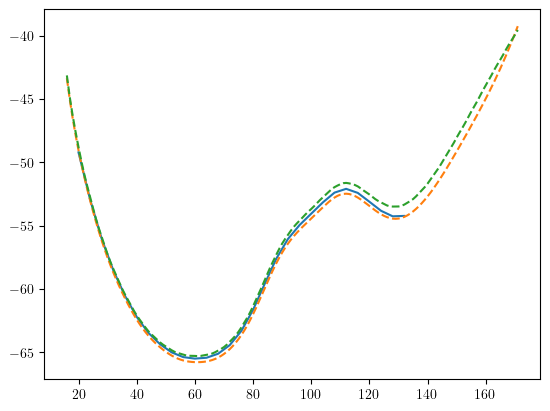

In [53]:
r_old = np.arange(20.0, 132.0 + 4.0, 4.0)

plt.plot(r_old, r_old**2*xi_old[1])
plt.plot(cfg.r, cfg.r**2*xi[1], ls='--')
plt.plot(cfg.r, cfg.r**2*xi_test[1], ls='--')


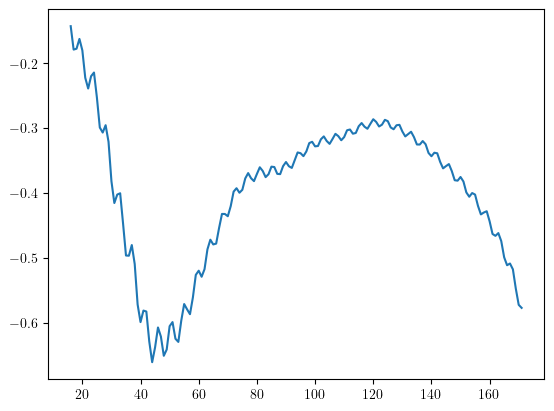

In [47]:
plt.plot(cfg.r, (xi_test[2]-xi[2])/xi[2])
#plt.ylim((-0.03, 0.03))

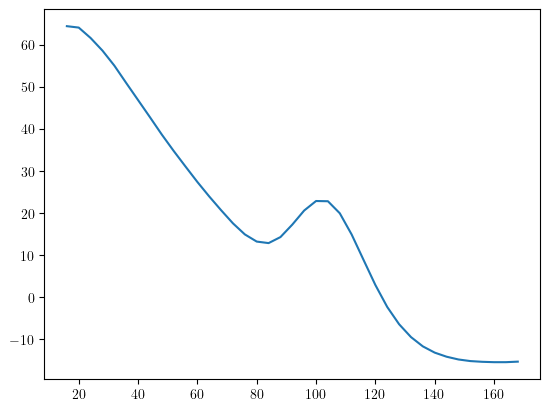

In [8]:
plt.plot(cfg.r, cfg.r**2*xi[0])

In [ ]:
from compact.emulator import MultipoleEmulator, validation_error

OUT_DIR = '/spiffball/cosweeney/data/training/compact_multipole_training_set/z0p5/'
thetas = np.load(OUT_DIR + 'thetas.npy')      # (N, 6)
xi     = np.load(OUT_DIR + 'xi.npy')          # (N, 3, n_r)
s      = np.load(OUT_DIR + 's.npy')

good = np.isfinite(xi).all(axis=(1, 2)) & (np.abs(xi).max(axis=(1, 2)) < 10) & (xi[:, 0, 0] > 0.0)
thetas, xi = thetas[good], xi[good]
print(f"{good.sum()} / {good.size} usable")

# fit in the coordinate the design was drawn in
theta_emu = thetas.copy()
theta_emu[:, 5] = np.log(1e10 * thetas[:, 5])

perm = np.random.default_rng(0).permutation(len(theta_emu))
test, train = perm[:len(perm) // 5], perm[len(perm) // 5:]

emu = MultipoleEmulator(theta_emu[train], xi[train], n_pca=12)
print(emu.var_ratio.cumsum(0).numpy())

err = validation_error(emu, theta_emu[test], xi[test])   # (n_test, 3, n_r)
for i, l in enumerate((0, 2, 4)):
    print(f"ell={l}: 68th {np.percentile(err[:, i], 68):.3f}, "
          f"95th {np.percentile(err[:, i], 95):.3f}, worst bin "
          f"{s[np.percentile(err[:, i], 95, axis=0).argmax()]:.0f}")

7940 / 8192 usable
[0.31118285 0.50649892 0.66536944 0.78270928 0.86636231 0.90126116
 0.92810759 0.94342175 0.95354788 0.96217174 0.96918896 0.97494911]
ell=0: 68th 0.163, 95th 0.433, worst bin 16
ell=2: 68th 0.111, 95th 0.331, worst bin 16
ell=4: 68th 0.103, 95th 0.297, worst bin 17


In [35]:
xi.shape

(4093, 3, 156)

In [74]:


OUT_DIR = '/spiffball/cosweeney/data/training/compact_multipole_training_set/z0p5/'
thetas = np.load(OUT_DIR + 'thetas.npy')
xi = np.load(OUT_DIR + 'xi.npy')
s = np.load(OUT_DIR + 's.npy')

good = np.isfinite(xi).all(axis=(1, 2)) & (np.abs(xi).max(axis=(1, 2)) < 10) & (xi[:, 0, 0] > 0.0)
thetas, xi = thetas[good], xi[good]

theta_emu = thetas.copy()
theta_emu[:, 5] = np.log(1e10 * thetas[:, 5])

# one fixed test set for every run below, so the numbers are comparable
perm = np.random.default_rng(0).permutation(len(theta_emu))
n_test = len(perm) // 5
test, pool = perm[:n_test], perm[n_test:]


def fit_report(xi_in, n_pca=12, n_train=None, label=''):
    train = pool if n_train is None else pool[:n_train]
    emu = MultipoleEmulator(theta_emu[train], xi_in[train], n_pca=n_pca)
    err = validation_error(emu, theta_emu[test], xi_in[test])
    print(f"{label:24s} N={len(train):4d} pca={n_pca:2d} "
          f"kept={emu.var_ratio.sum():.5f} "
          f"68th={np.percentile(err, 68):.4f} 95th={np.percentile(err, 95):.4f}")
    return emu, err


# --- A. is it truncation or fit error?
# if the percentiles are flat across n_pca, the basis is fine and the
# quadratic-in-theta step is what's failing.
print("A. PCA truncation")
for n_pca in (4, 8, 12, 20):
    fit_report(xi, n_pca=n_pca, label='raw')

# --- B. divide out the analytically known amplitude
# xi ~ (1+b1)^2 * As at leading order; exp(lnAs) over a factor ~7 is not
# quadratic, so making the emulator learn it wastes the expansion.
print("\nB. amplitude removed")
amp = (1 + thetas[:, 0])**2 * thetas[:, 5]
xi_shape = xi / amp[:, None, None]
fit_report(xi, label='raw')
fit_report(xi_shape, label='xi / (1+b1)^2 As')

# --- C. learning curve
# plateau  => quadratic is the wrong model over these priors (bias-limited)
# falling  => more training points would still help (variance-limited)
print("\nC. learning curve")
for n in (128, 256, 512, len(pool)):
    fit_report(xi_shape, n_train=n, label='shape')

# --- D. is the training data itself noisy at small s?
# second difference along s, relative to the multipole amplitude. the streaming
# integral is hardest at small s, and the worst-fit bins landed there.
print("\nD. training-set roughness by s")
d2 = np.abs(np.diff(xi_shape, n=2, axis=2)).mean(axis=0)
scale = np.abs(xi_shape).mean(axis=(0, 2))[:, None]
rough = d2 / scale
for i, l in enumerate((0, 2, 4)):
    print(f"ell={l}: " + "  ".join(f"{s[j+1]:5.1f}:{rough[i, j]:7.4f}"
                                   for j in (0, 1, 2, len(s)//2, len(s)-3)))

A. PCA truncation
raw                      N=6352 pca= 4 kept=0.78271 68th=0.1418 95th=0.5110
raw                      N=6352 pca= 8 kept=0.94342 68th=0.1264 95th=0.3696
raw                      N=6352 pca=12 kept=0.97495 68th=0.1242 95th=0.3627
raw                      N=6352 pca=20 kept=0.99372 68th=0.1134 95th=0.3388

B. amplitude removed
raw                      N=6352 pca=12 kept=0.97495 68th=0.1242 95th=0.3627
xi / (1+b1)^2 As         N=6352 pca=12 kept=0.98607 68th=0.0944 95th=0.3249

C. learning curve
shape                    N= 128 pca=12 kept=0.99966 68th=0.3676 95th=0.9634
shape                    N= 256 pca=12 kept=0.99930 68th=0.2160 95th=0.6044
shape                    N= 512 pca=12 kept=0.99950 68th=0.1849 95th=0.5642
shape                    N=6352 pca=12 kept=0.98607 68th=0.0944 95th=0.3249

D. training-set roughness by s
ell=0:  17.0: 0.4955   18.0: 0.3919   19.0: 0.3262   95.0: 0.0279  170.0: 0.0260
ell=2:  17.0: 0.4092   18.0: 0.3060   19.0: 0.2560   95.0: 0.0481  1

In [12]:
xi.shape

(4093, 3, 156)

In [57]:
print(np.corrcoef(xi[:, 0, 5], xi[:, 2, 25])[0, 1])
print(np.ptp(np.log(np.abs(xi[:, 0, 5]))))

-0.9999999999999857
50.28695562900876


In [61]:
xi_real = UnivariateSpline(cfg.r_lpt, model._lpt[0], s=0)
print(xi_real([100.0, 165.0, 206.0, 264.0]))

[ 0.00191639 -0.00035383  0.00037027  0.0059771 ]


In [62]:
print(xi[:5, 0, 5])

[0.5025176  0.51750553 0.110053   0.05984758 0.3907977 ]


In [63]:
amp = np.abs(xi).max(axis=(1, 2))
print(np.sort(amp)[-10:])
bad = amp > 10
print(np.where(bad)[0])
print(thetas[bad])

[4.84687028e+00 4.99287765e+00 5.18785385e+00 5.46148856e+00
 5.54745785e+00 5.69187284e+00 5.91279767e+00 7.36630544e+00
 8.42839801e+00 6.29024335e+20]
[407]
[[ 7.05690298e-01 -5.94320484e-01  2.07596439e-02  1.39748588e-01
   5.70204051e-01  5.37642971e-09]]


In [65]:
m = CompactStreamingModel(redshift=0.5, config=cfg)
test = m.predict(thetas[407], ells=(0, 2, 4))

(-75.0, 120.0)

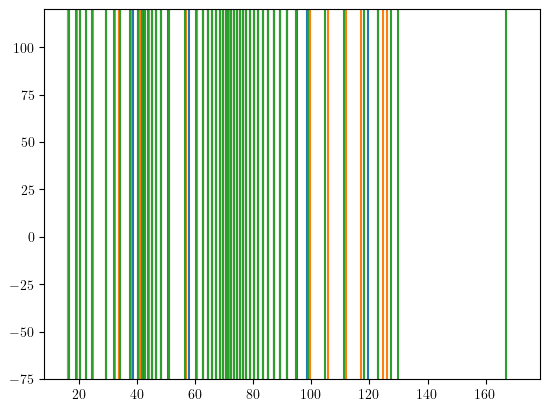

In [67]:
plt.plot(cfg.r, cfg.r**2*test[0])
plt.plot(cfg.r, cfg.r**2*test[1])
plt.plot(cfg.r, cfg.r**2*test[2])

plt.ylim((-75, 120))

In [76]:
OUT_DIR = '/spiffball/cosweeney/data/training/compact_mono_quad_training_set/z0p5/'

mono, quad = xi[:, 0], xi[:, 1]
thetas = np.load(OUT_DIR+'thetas.npy')

nan_mono = np.isnan(mono).any(axis=1)
nan_quad = np.isnan(quad).any(axis=1)
print(f"{nan_mono.sum()} samples with NaN monopole, {nan_quad.sum()} with NaN quadrupole")

# unphysical magnitude check -- xi shouldn't blow up
huge = (np.abs(mono) > 1e4).any(axis=1) | (np.abs(quad) > 1e4).any(axis=1)
print(f"{huge.sum()} samples with |xi| > 1e4 anywhere")

bad = nan_mono | nan_quad | huge
if bad.any():
    print("Bad theta rows:\n", thetas[bad])

0 samples with NaN monopole, 0 with NaN quadrupole
0 samples with |xi| > 1e4 anywhere


In [11]:
mono.shape

(1024, 29)

In [9]:
cfg.r.shape

(156,)

In [78]:
xi.shape

(7940, 3, 156)

TypeError: 'numpy.ndarray' object is not callable

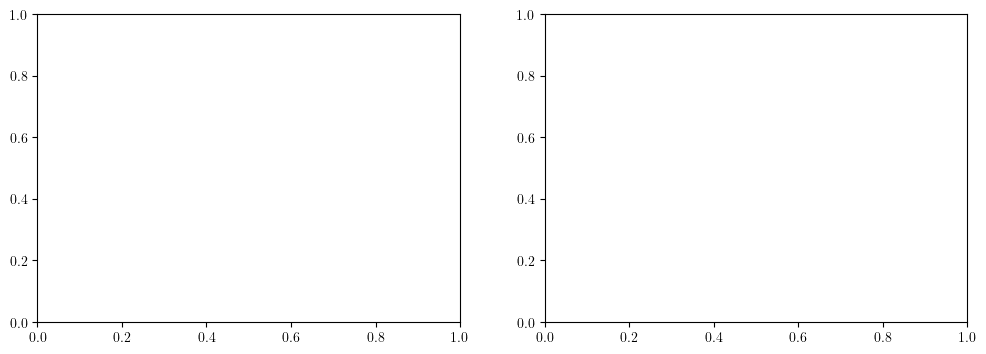

In [77]:
import compact.config as cfg

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for name, arr, a in [('monopole', mono, ax[0]), ('quadrupole', quad, ax[1])]:
    good = ~np.isnan(arr).any(axis=1) (xi[:, 0, 0] > 0.0)
    a.fill_between(cfg.r, np.nanpercentile(arr[good], 2, axis=0),
                          np.nanpercentile(arr[good], 98, axis=0), alpha=0.3)
    a.plot(cfg.r, np.nanmedian(arr[good], axis=0), c='k')
    for i in np.random.choice(np.where(good)[0], 30, replace=False):
        a.plot(cfg.r, arr[i], lw=0.5, alpha=0.4)
    a.set_title(name)

#ax[0].set_ylim((-100, 150))

#ax[1].set_ylim((-100, 25))

In [20]:
np.argmin(mono[:, 0])

np.int64(55)

In [28]:
np.sum(mono[:, 0] < 0.0)

np.int64(130)

In [30]:
np.argwhere(mono[:, 0] < 0.0)

array([[  21],
       [  45],
       [  55],
       [  63],
       [  71],
       [  73],
       [  87],
       [ 131],
       [ 163],
       [ 175],
       [ 213],
       [ 273],
       [ 281],
       [ 315],
       [ 351],
       [ 393],
       [ 436],
       [ 470],
       [ 494],
       [ 524],
       [ 546],
       [ 578],
       [ 612],
       [ 624],
       [ 668],
       [ 674],
       [ 686],
       [ 688],
       [ 715],
       [ 758],
       [ 790],
       [ 816],
       [ 900],
       [ 912],
       [ 916],
       [ 934],
       [ 948],
       [ 962],
       [1056],
       [1140],
       [1184],
       [1198],
       [1248],
       [1357],
       [1361],
       [1387],
       [1399],
       [1405],
       [1465],
       [1469],
       [1471],
       [1499],
       [1603],
       [1621],
       [1635],
       [1667],
       [1697],
       [1731],
       [1751],
       [1757],
       [1827],
       [1829],
       [1849],
       [1873],
       [1917],
       [1955],
       [19

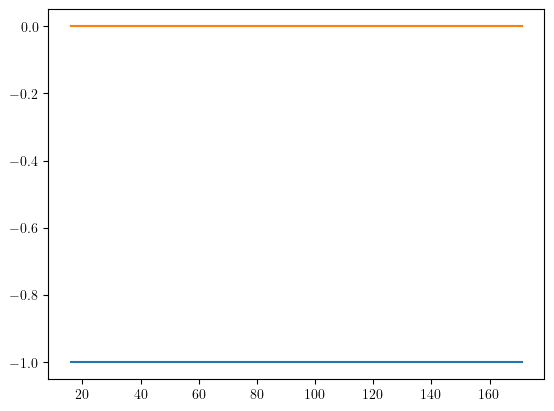

In [39]:
#plt.plot(cfg.r, mono[0])
plt.plot(cfg.r, mono[55])
plt.plot(cfg.r, quad[55])

30 collapsed, 0 noisy, 30 total of 50000  (0.1%)
  Om   bad: [0.1703, 0.5318]   all: [0.1546, 0.5380]
  h    bad: [0.5507, 0.8978]   all: [0.5500, 0.9000]
  b1   bad: [0.0201, 1.8262]   all: [0.0000, 2.0000]


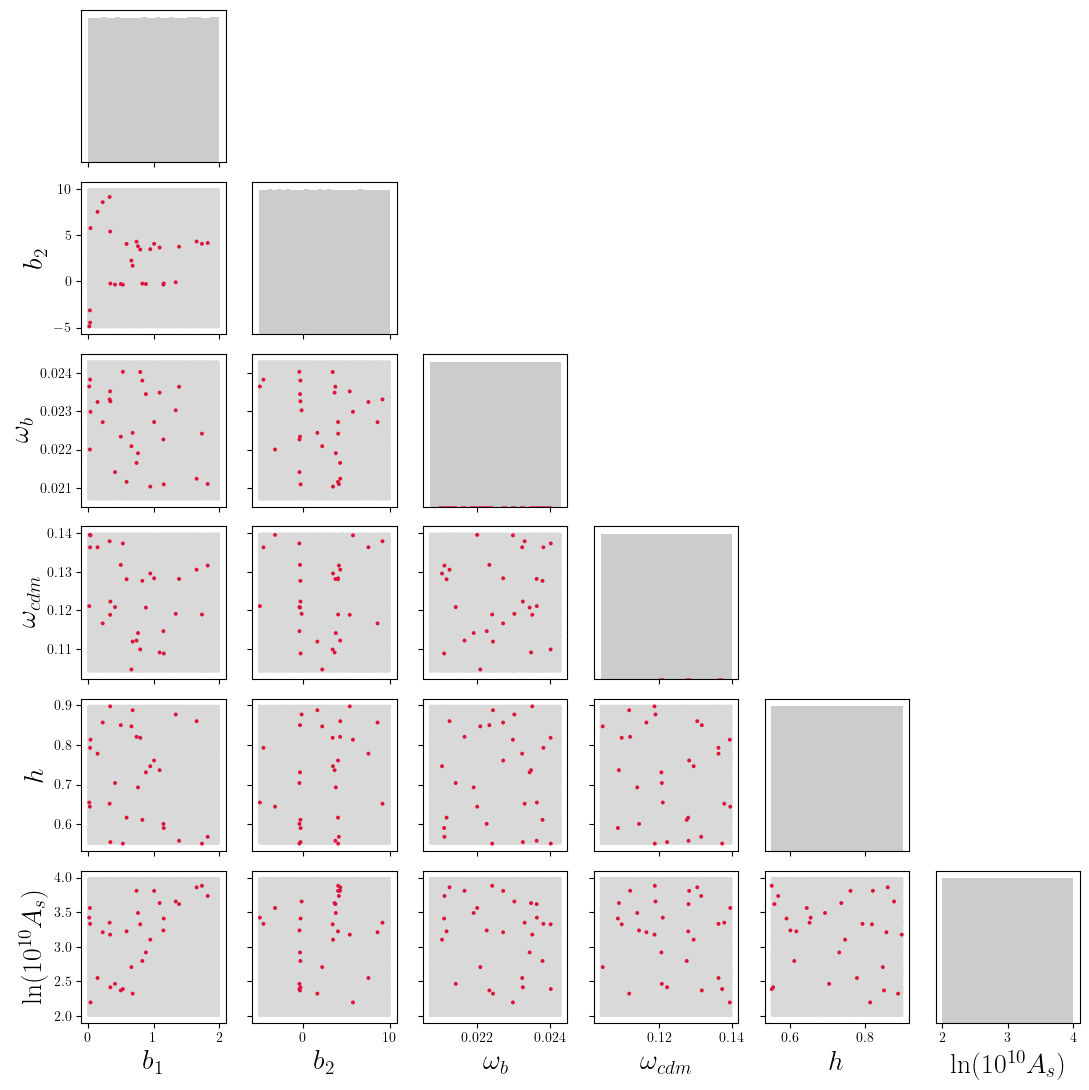

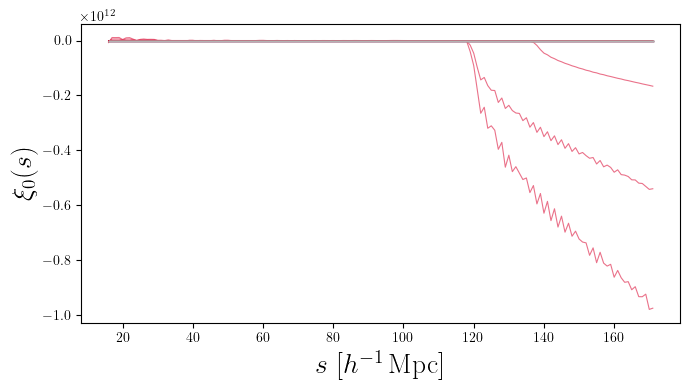

In [2]:

import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = '/spiffball/cosweeney/data/training/compact_multipole_training_set/z0p5/'
thetas = np.load(OUT_DIR + 'thetas_train.npy')
xi = np.load(OUT_DIR + 'xi_train.npy')
s = np.load(OUT_DIR + 's.npy')

xi0 = xi[:, 0]

# xi_s = integral - 1, so xi0 -> -1 means the streaming integral returned ~0
collapsed = np.median(xi0, axis=1) < -0.5

# second differences along s, relative to each sample's own amplitude
rough = (np.abs(np.diff(xi0, n=2, axis=1)).mean(axis=1)
         / np.abs(xi0).mean(axis=1))
noisy = rough > 5 * np.median(rough)

bad = collapsed | noisy
print(f"{collapsed.sum()} collapsed, {noisy.sum()} noisy, {bad.sum()} total "
      f"of {len(bad)}  ({100 * bad.mean():.1f}%)")

# derived quantities are often the real discriminant
Om = (thetas[:, 2] + thetas[:, 3]) / thetas[:, 4]**2
for name, v in [('Om', Om), ('h', thetas[:, 4]), ('b1', thetas[:, 0])]:
    print(f"  {name:3s}  bad: [{v[bad].min():.4f}, {v[bad].max():.4f}]   "
          f"all: [{v.min():.4f}, {v.max():.4f}]")

# plot in the coordinates the design was drawn in, so the good points look uniform
plot_theta = thetas.copy()
plot_theta[:, 5] = np.log(1e10 * thetas[:, 5])
labels = [r'$b_1$', r'$b_2$', r'$\omega_b$', r'$\omega_{cdm}$',
          r'$h$', r'$\ln(10^{10}A_s)$']

n = plot_theta.shape[1]
fig, axes = plt.subplots(n, n, figsize=(11, 11))
for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if j > i:
            ax.axis('off')
            continue
        if i == j:
            bins = np.linspace(plot_theta[:, i].min(), plot_theta[:, i].max(), 30)
            ax.hist(plot_theta[~bad, i], bins=bins, color='0.8')
            ax.hist(plot_theta[bad, i], bins=bins, color='crimson', alpha=0.7)
            ax.set_yticks([])
        else:
            ax.scatter(plot_theta[~bad, j], plot_theta[~bad, i],
                       s=2, c='0.85', edgecolors='none', rasterized=True)
            ax.scatter(plot_theta[bad, j], plot_theta[bad, i],
                       s=8, c='crimson', edgecolors='none')
        if i == n - 1:
            ax.set_xlabel(labels[j])
        else:
            ax.set_xticklabels([])
        if j == 0 and i > 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])

fig.tight_layout()
fig.savefig(OUT_DIR + 'bad_samples_corner.png', dpi=130)

# what the failures actually look like
fig2, ax = plt.subplots(figsize=(7, 4))
for k in np.where(bad)[0][:20]:
    ax.plot(s, xi0[k], lw=0.8, c='crimson', alpha=0.6)
for k in np.where(~bad)[0][:20]:
    ax.plot(s, xi0[k], lw=0.8, c='0.7')
ax.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
ax.set_ylabel(r'$\xi_0(s)$')
fig2.tight_layout()

In [52]:
from compact.predictions import *
from compact.config import *

cfg = Config()

k = 55#np.where(collapsed)[0][0]
b1, b2, ob, oc, h, As = thetas[k]
m = CompactStreamingModel(redshift=0.5, config=cfg)
lpt = m._lpt_inputs((h, ob, oc, As), np.array([b1, b2]))
print('max |v_mean| =', np.abs(lpt[1]).max())
print('compact params =', m._compact_params((h, ob, oc, As)))

max |v_mean| = 2.0938432438991787e+25
compact params = [3.77917514e+02 3.13257673e-01 1.13524138e+02 3.33482853e+01
 1.03785621e+02 7.41186984e-01]


In [27]:
thetas[55]

array([ 6.73531717e-01, -1.59344759e+00,  2.21660348e-02,  1.05443400e-01,
        5.61347726e-01,  2.99126319e-09])

[11.4289319   6.62202291  4.69793044  3.63798441  2.96804847  2.51220831
  2.18800174  1.95072745  1.7735119   1.63897785  1.53532553  1.45426576
  1.38986328  1.33782004  1.29504639  1.25932155  1.22906202  1.20314292
  1.18076448  1.16133842  1.14442769  1.12967385  1.11678347  1.10549757
  1.09558462  1.08683838  1.07908274  1.07216322  1.06595779  1.06036335
  1.05530716  1.05072721  1.04657895  1.04282066  1.03941914  1.03633948
  1.03354902  1.03101494  1.02870582  1.02659488  1.0246553   1.02286777
  1.02121696  1.01969024  1.01827866  1.01697578  1.01577433  1.01466699
  1.01364786  1.01270712  1.01183741  1.01102995  1.01027701  1.00957238
  1.00891131  1.00829058  1.00770827  1.00716336  1.00665577  1.00618505
  1.00575015  1.00535117  1.00498608  1.00465488  1.00435588  1.0040895
  1.00385608  1.0036563   1.00349162  1.00336358  1.00327343  1.00322147
  1.00320658  1.00322646  1.00327758  1.00335451  1.00345084  1.00355943
  1.00367285  1.00378371  1.00388453  1.0039692   1.

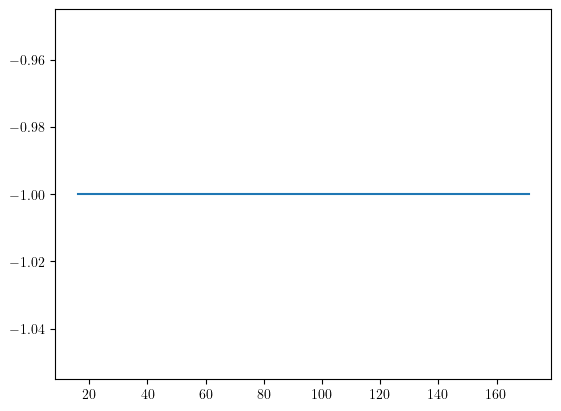

In [53]:
test = m.predict(thetas[55], ells=(0, 2, 4))

plt.plot(cfg.r, test[0])

In [55]:
kk = 55
b1, b2, ob, oc, h, As = thetas[k]
m = CompactStreamingModel(redshift=0.5, config=cfg)
lpt = m._lpt_inputs((h, ob, oc, As), np.array([b1, b2]))
pdf = m._pdf(lpt, (h, ob, oc, As))

print('params  =', m._compact_params((h, ob, oc, As)))
print('conv    =', lpt[-1])
print('v_mean  =', np.abs(lpt[1]).min(), np.abs(lpt[1]).max())

v = np.linspace(-206, 206, 300)          # r_par nodes, in Mpc/h
for rp, rl in [(30.0, 30.0), (5.0, 60.0), (60.0, 5.0)]:
    p = pdf(v, rp, rl)
    print(f"rp={rp:5.1f} rl={rl:5.1f}  sum={np.trapz(p, v):.4f}  "
          f"max={np.nanmax(p):.3e}  argmax_v={v[np.nanargmax(p)]:7.2f}  "
          f"nan={np.isnan(p).sum()}")

params  = [3.77917514e+02 3.13257673e-01 1.13524138e+02 3.33482853e+01
 1.03785621e+02 7.41186984e-01]
conv    = 93.50273817934483
v_mean  = 4.513205745328109e+20 2.0938432438991787e+25
rp= 30.0 rl= 30.0  sum=0.0000  max=3.948e-147  argmax_v=-206.00  nan=0
rp=  5.0 rl= 60.0  sum=0.0000  max=1.694e-146  argmax_v=-206.00  nan=0
rp= 60.0 rl=  5.0  sum=0.0000  max=1.608e-139  argmax_v=-206.00  nan=0


In [56]:
gli = GetLPTInputs(0.5, (h, ob, oc, As), np.concatenate(([b1, b2], np.zeros(7))))
gli.get_pklin_gsm()
gli.gsm.compute_cumulants(b1, b2, *np.zeros(7))
print(gli.gsm.rint.min(), gli.gsm.rint.max())
print(np.abs(gli.gsm.veft).max(), np.abs(gli.gsm.xieft).max())
print(gli.gsm.rint[np.abs(gli.gsm.veft).argmax()])
print(gli.Plin.min(), gli.Plin.max(), gli.f)

0.10011522437649635 599.0241907149397
8.100133808241827e+33 57.38855690968952
0.101976975100683
0.023284781642093945 14085.940609040288 0.8185096392921615


In [57]:
r = gli.gsm.rint
print(r[:20])
print(np.abs(gli.gsm.veft)[:20])
print(np.abs(gli.pwv_mean(cfg.r_lpt, np.concatenate(([b1, b2], np.zeros(7))))[:10]))

[0.10011522 0.10057745 0.10104181 0.10150832 0.10197698 0.1024478
 0.10292079 0.10339597 0.10387335 0.10435292 0.10483472 0.10531873
 0.10580498 0.10629348 0.10678423 0.10727725 0.10777254 0.10827012
 0.10877    0.10927219]
[9.85248589e+32 2.97605868e+33 6.19538442e+33 8.02026142e+33
 8.10013381e+33 6.45888107e+33 3.48768501e+33 1.41248893e+32
 3.62237207e+33 6.19426064e+33 7.30795597e+33 6.74844800e+33
 4.68130947e+33 1.61291670e+33 1.72770975e+33 4.55906039e+33
 6.23016082e+33 6.37343961e+33 4.99065894e+33 2.45041348e+33]
[2.09384324e+25 3.81993651e+24 5.44706464e+24 1.17199522e+24
 6.91358633e+24 1.44665913e+24 5.97415983e+24 6.08363105e+24
 1.68649151e+24 3.78354181e+22]


In [59]:
gli = GetLPTInputs(0.5, (h, ob, oc, As), np.concatenate(([b1, b2], np.zeros(7))))
gli.kmax = 100.0
camb_pars = camb.set_params(H0=100.0*h, ombh2=ob, omch2=oc, As=As, ns=0.9649)
camb_pars.NonLinear = camb.model.NonLinear_none
camb_pars.set_matter_power(redshifts=[0.5], kmax=2*100.0*h)
gli.results = camb.get_results(camb_pars)

k, _, pk = gli.results.get_matter_power_spectrum(minkh=1e-5, maxkh=100.0, npoints=2048)
g = GaussianStreamingModel(k, pk[0])
g.convert_sigma_bases()
g.compute_cumulants(b1, b2, *np.zeros(7))
print(np.abs(g.veft).max())

1.2432990430454075e+34


In [60]:
from velocileptors.LPT.gaussian_streaming_model_fftw import GaussianStreamingModel

def probe(theta, label):
    b1, b2, ob, oc, h, As = theta
    gli = GetLPTInputs(0.5, (h, ob, oc, As), np.concatenate(([b1, b2], np.zeros(7))))
    gli.get_pklin_gsm()
    g = gli.gsm
    g.compute_cumulants(b1, b2, *np.zeros(7))
    print(f"{label}  b1={b1:.3f} b2={b2:+.3f} ob={ob:.4f} oc={oc:.4f} "
          f"h={h:.3f} lnAs={np.log(1e10*As):.3f}")
    print(f"   |veft|max={np.abs(g.veft).max():.3e}  at r={g.rint[np.abs(g.veft).argmax()]:.3f}")
    print(f"   |xieft|max={np.abs(g.xieft).max():.3e}  "
          f"|s0eft|max={np.abs(g.s0eft).max():.3e}")
    print(f"   veft[:5]={np.array2string(g.veft[:5], precision=2)}")
    print(f"   Plin range=[{gli.Plin.min():.3e}, {gli.Plin.max():.3e}]  f={gli.f:.4f}")

healthy = np.where(~bad)[0][:3]
for i in healthy:
    probe(thetas[i], f"OK  [{i}]")
probe(thetas[55], "BAD [ 55]")

OK  [0]  b1=0.862 b2=+7.216 ob=0.0236 oc=0.1059 h=0.654 lnAs=3.680
   |veft|max=5.355e+01  at r=2.212
   |xieft|max=2.563e+04  |s0eft|max=8.471e+02
   veft[:5]=[-25.5  -25.55 -25.6  -25.64 -25.69]
   Plin range=[2.977e-02, 2.725e+04]  f=0.7501
OK  [1]  b1=1.824 b2=-2.403 ob=0.0216 oc=0.1290 h=0.861 lnAs=2.740
   |veft|max=9.833e+00  at r=6.652
   |xieft|max=2.373e+02  |s0eft|max=9.353e+02
   veft[:5]=[-0.29 -0.29 -0.29 -0.29 -0.3 ]
   Plin range=[1.767e-02, 1.869e+04]  f=0.6538
OK  [2]  b1=1.027 b2=+2.934 ob=0.0232 oc=0.1182 h=0.780 lnAs=2.040
   |veft|max=1.003e+02  at r=0.100
   |xieft|max=1.155e+03  |s0eft|max=1.178e+02
   veft[:5]=[-100.28 -100.    -99.72  -99.45  -99.17]
   Plin range=[7.186e-03, 7.642e+03]  f=0.6863
BAD [ 55]  b1=0.674 b2=-1.593 ob=0.0222 oc=0.1054 h=0.561 lnAs=3.398
   |veft|max=8.100e+33  at r=0.102
   |xieft|max=5.739e+01  |s0eft|max=4.913e+02
   veft[:5]=[-9.85e+32  2.98e+33  6.20e+33  8.02e+33  8.10e+33]
   Plin range=[2.328e-02, 1.409e+04]  f=0.8185


In [66]:
b1, b2, ob, oc, h, As = thetas[55]
gli = GetLPTInputs(0.5, (h, ob, oc, As), np.concatenate(([b1, b2], np.zeros(7))))
gli.get_pklin_gsm()
gli.gsm.compute_cumulants(b1, b2, *np.zeros(7))
print(np.abs(gli.gsm.veft).max())

8.100133808241827e+33


In [67]:
print([a for a in dir(gli.gsm) if not a.startswith('_')])

['N', 'Tdddot', 'Tddot', 'Tdot', 'Tloop', 'U11', 'U11dot', 'U20', 'U20dot', 'U3', 'Ub3', 'Ub3dot', 'Udot', 'Ulin', 'Uloopdot', 'Us2', 'Us2dot', 'V', 'V12dot', 'Vdddot', 'Vddot', 'Vdot', 'Vloop', 'X10', 'X10ddot', 'X10dot', 'XYlin', 'Xddot', 'Xdot', 'Xlin', 'Xloop', 'Xloopddot', 'Xloopdot', 'Xs2', 'Xs2ddot', 'Xs2dot', 'Y10', 'Y10ddot', 'Y10dot', 'Yddot', 'Ydot', 'Ylin', 'Yloop', 'Yloopddot', 'Yloopdot', 'Ys2', 'Ys2ddot', 'Ys2dot', 'beyond_gauss', 'chi', 'combine_bias_terms_gk', 'combine_bias_terms_kk', 'combine_bias_terms_pk', 'combine_bias_terms_pk_crossmatter', 'combine_bias_terms_sk', 'combine_bias_terms_vk', 'compute_cumulants', 'compute_xi_ell', 'compute_xi_real', 'compute_xi_rsd', 'convert_gamma_bases', 'convert_kappa_bases', 'convert_sigma_bases', 'corlin', 'cutoff', 'export_wisdom', 'extrap_max', 'extrap_min', 'gamma1_integrals', 'gamma2_integrals', 'import_wisdom', 'jn', 'k', 'kappa_integrals', 'kdelta_Wddot', 'kint', 'kmax', 'kmin', 'kv', 'make_gamma1table', 'make_gamma2table'

In [68]:
b1, b2, ob, oc, h, As = thetas[55]
good0 = thetas[0]

pars = np.concatenate(([b1, b2], np.zeros(7)))
for t in np.linspace(0, 1, 21):
    th = (1 - t) * good0 + t * thetas[55]
    g = GetLPTInputs(0.5, (th[4], th[2], th[3], th[5]),
                     np.concatenate((th[:2], np.zeros(7))))
    g.get_pklin_gsm()
    g.gsm.compute_cumulants(th[0], th[1], *np.zeros(7))
    print(f"t={t:.2f}  |veft|max={np.abs(g.gsm.veft).max():.3e}")

t=0.00  |veft|max=5.355e+01
t=0.05  |veft|max=4.969e+01
t=0.10  |veft|max=4.593e+01
t=0.15  |veft|max=4.227e+01
t=0.20  |veft|max=3.870e+01
t=0.25  |veft|max=3.525e+01
t=0.30  |veft|max=3.192e+01
t=0.35  |veft|max=2.872e+01
t=0.40  |veft|max=2.566e+01
t=0.45  |veft|max=2.276e+01
t=0.50  |veft|max=2.003e+01
t=0.55  |veft|max=1.749e+01
t=0.60  |veft|max=1.514e+01
t=0.65  |veft|max=1.300e+01
t=0.70  |veft|max=1.107e+01
t=0.75  |veft|max=9.364e+00
t=0.80  |veft|max=7.880e+00
t=0.85  |veft|max=6.614e+00
t=0.90  |veft|max=5.553e+00
t=0.95  |veft|max=4.673e+00
t=1.00  |veft|max=8.100e+33


excluded 317 of 8192: 0 nonfinite, 3 huge, 242 collapsed, 80 noisy
cumulative variance: [0.32771 0.53092 0.66097 0.76327 0.82446 0.86155 0.8895  0.91431 0.93142
 0.94595 0.95749 0.96724]
ell=0: 68th=0.1958 95th=0.5905 worst s=94
ell=2: 68th=0.1166 95th=0.2873 worst s=16
ell=4: 68th=0.1827 95th=0.5333 worst s=61


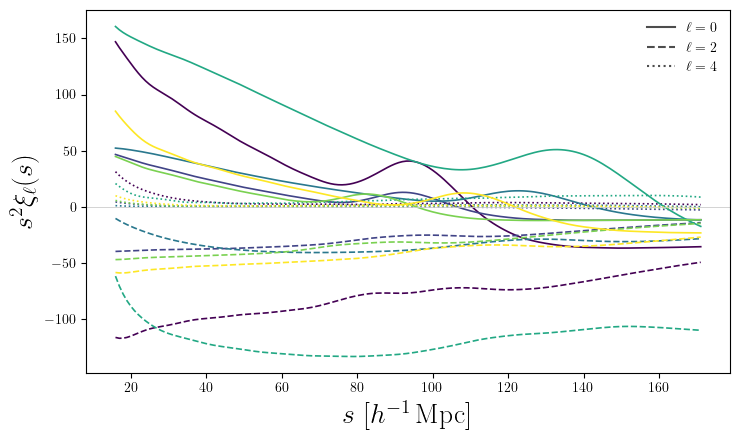

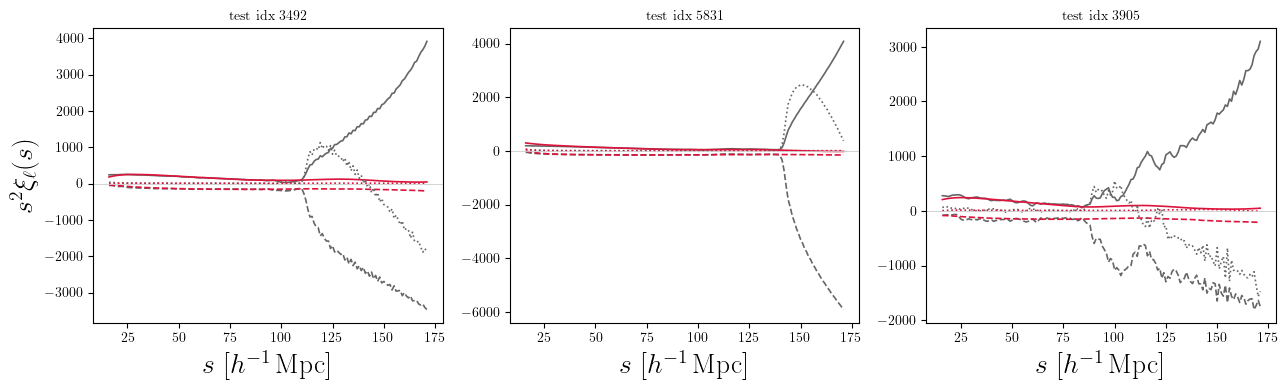

In [80]:
"""
Train/validate the quadratic emulator with the flagged (collapsed / noisy)
predictions removed, and plot multipoles for inspection.
"""

import numpy as np
import matplotlib.pyplot as plt
from compact.emulator import MultipoleEmulator, validation_error

OUT_DIR = '/spiffball/cosweeney/data/training/compact_multipole_training_set/z0p5/'
thetas = np.load(OUT_DIR + 'thetas.npy')
xi = np.load(OUT_DIR + 'xi.npy')
s = np.load(OUT_DIR + 's.npy')
ELLS = (0, 2, 4)

# ------------------------------------------------------------------ flagging
xi0 = xi[:, 0]
finite = np.isfinite(xi).all(axis=(1, 2))
huge = np.abs(xi).max(axis=(1, 2)) > 10

# a collapsed integral gives xi_s(s,mu) = -1 identically, so the monopole sits
# at -1 and the higher multipoles project to zero -- both signatures together
collapsed = (np.median(xi0, axis=1) < -0.5) | (np.abs(xi[:, 1]).max(axis=1) < 1e-8)

rough = np.abs(np.diff(xi0, n=2, axis=1)).mean(axis=1) / np.abs(xi0).mean(axis=1)
noisy = rough > 5 * np.median(rough[~collapsed & finite])

bad = ~finite | huge | collapsed | noisy
print(f"excluded {bad.sum()} of {len(bad)}: {(~finite).sum()} nonfinite, "
      f"{huge.sum()} huge, {collapsed.sum()} collapsed, {noisy.sum()} noisy")

thetas, xi = thetas[~bad], xi[~bad]

# ------------------------------------------------------------------ fit
theta_emu = thetas.copy()
theta_emu[:, 5] = np.log(1e10 * thetas[:, 5])
amp = (1 + thetas[:, 0])**2 * thetas[:, 5]
xi_shape = xi / amp[:, None, None]

perm = np.random.default_rng(0).permutation(len(theta_emu))
n_test = len(perm) // 5
test, train = perm[:n_test], perm[n_test:]

emu = MultipoleEmulator(theta_emu[train], xi_shape[train], n_pca=12)
print('cumulative variance:', np.round(emu.var_ratio.cumsum(0).numpy(), 5))

err = validation_error(emu, theta_emu[test], xi_shape[test])
for i, l in enumerate(ELLS):
    p95 = np.percentile(err[:, i], 95, axis=0)
    print(f"ell={l}: 68th={np.percentile(err[:, i], 68):.4f} "
          f"95th={np.percentile(err[:, i], 95):.4f} worst s={s[p95.argmax()]:.0f}")

# ------------------------------------------------------------------ plots
styles = {0: '-', 2: '--', 4: ':'}


def plot_samples(idx, ax=None):
    """s^2 xi_ell for the given training samples, all three ells overlaid."""
    ax = ax or plt.subplots(figsize=(7.5, 4.5))[1]
    for n, k in enumerate(np.atleast_1d(idx)):
        c = plt.cm.viridis(n / max(len(np.atleast_1d(idx)) - 1, 1))
        for i, l in enumerate(ELLS):
            ax.plot(s, s**2 * xi[k, i], styles[l], color=c, lw=1.2)
    for l in ELLS:
        ax.plot([], [], styles[l], color='0.3', label=rf'$\ell={l}$')
    ax.axhline(0, color='0.8', lw=0.6)
    ax.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
    ax.set_ylabel(r'$s^2\xi_\ell(s)$')
    ax.legend(frameon=False)
    return ax


fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_samples(np.random.default_rng(1).choice(len(xi), 6, replace=False), ax=ax)
fig.tight_layout()
#fig.savefig(OUT_DIR + 'sample_multipoles.png', dpi=130)

# emulator vs truth for the worst test samples
pred = emu.predict(theta_emu[test]).numpy() * amp[test][:, None, None]
worst = err.max(axis=(1, 2)).argsort()[-3:]
fig2, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)
for a, w in zip(axes, worst):
    for i, l in enumerate(ELLS):
        a.plot(s, s**2 * xi[test[w], i], styles[l], color='0.4', lw=1.2)
        a.plot(s, s**2 * pred[w, i], styles[l], color='crimson', lw=1.2)
    a.axhline(0, color='0.8', lw=0.6)
    a.set_title(f'test idx {test[w]}', fontsize=10)
    a.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
axes[0].set_ylabel(r'$s^2\xi_\ell(s)$')
fig2.tight_layout()
#fig2.savefig(OUT_DIR + 'worst_predictions.png', dpi=130)

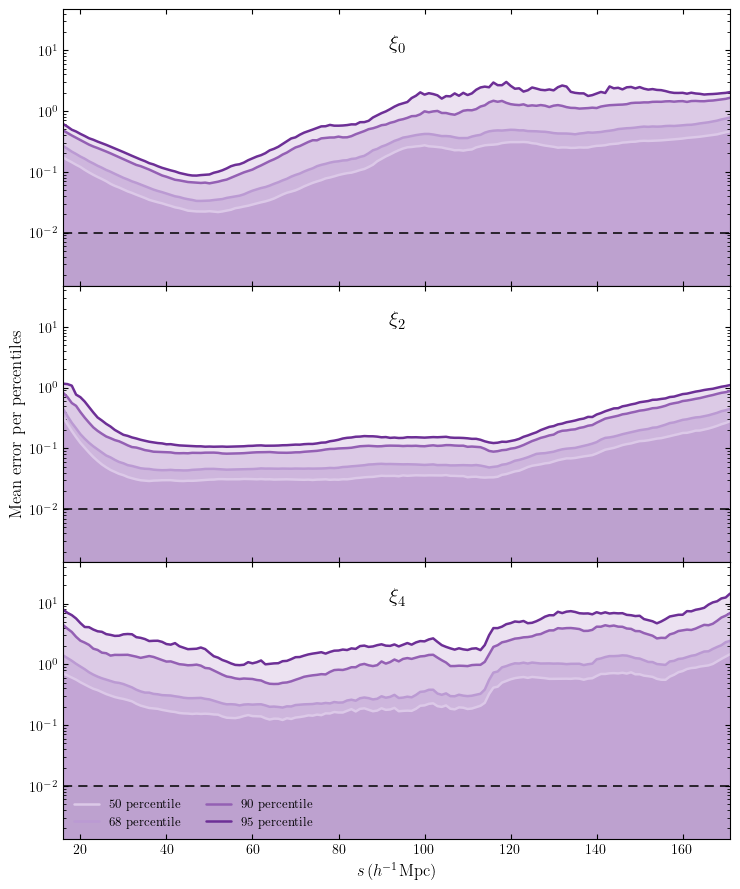

In [81]:
frac = np.abs(pred - xi[test]) / np.abs(xi[test])
pcts = [50, 68, 90, 95]
line_c = ['#dcc9e8', '#bb9ad3', '#9460b4', '#6d2f96']

lo = max(np.percentile(frac, 1), 1e-5)
hi = np.percentile(frac, 99.5) * 3

fig3, axes = plt.subplots(3, 1, figsize=(7.5, 9), sharex=True,
                          gridspec_kw={'hspace': 0})
for i, (ax, l) in enumerate(zip(axes, ELLS)):
    for p, c in zip(pcts, line_c):
        curve = np.percentile(frac[:, i], p, axis=0)
        ax.fill_between(s, lo * 1e-3, curve, color='#8a4fae', alpha=0.16, lw=0)
        ax.plot(s, curve, color=c, lw=1.8, label=f'{p} percentile',
                solid_capstyle='round')
    ax.axhspan(lo * 1e-3, 1e-2, color='#4d8b6a', alpha=0.07, lw=0, zorder=0)
    ax.axhline(1e-2, ls='--', c='k', lw=1.1, dashes=(6, 4))
    ax.set_yscale('log')
    ax.set_ylim(lo, hi)
    ax.set_xlim(s.min(), s.max())
    ax.text(0.5, 0.86, rf'$\xi_{l}$', transform=ax.transAxes,
            ha='center', fontsize=15)
    ax.tick_params(direction='in', which='both', top=True, right=True)

axes[1].set_ylabel('Mean error per percentiles', fontsize=12)
axes[-1].set_xlabel(r'$s\,(h^{-1}\mathrm{Mpc})$', fontsize=12)
axes[-1].legend(frameon=False, ncol=2, fontsize=9, loc='lower left')
fig3.tight_layout()


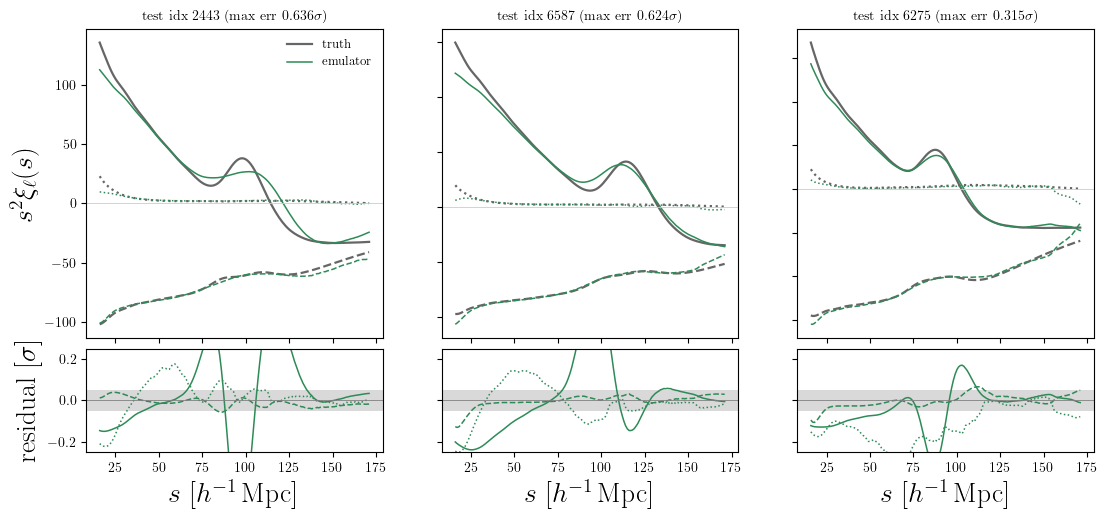

In [87]:
pred_shape = emu.predict(theta_emu[test]).numpy()
resid = (pred_shape - xi_shape[test]) / emu.y_std.reshape(len(ELLS), -1).numpy()

best = np.median(err, axis=(1, 2)).argsort()[:3]
fig4, axes = plt.subplots(2, 3, figsize=(13, 5.5), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
for col, w in enumerate(best):
    top, bot = axes[0, col], axes[1, col]
    for i, l in enumerate(ELLS):
        top.plot(s, s**2 * xi[test[w], i], styles[l], color='0.4', lw=1.6)
        top.plot(s, s**2 * pred[w, i], styles[l], color='seagreen', lw=1.1)
        bot.plot(s, resid[w, i], styles[l], color='seagreen', lw=1.1)
    top.axhline(0, color='0.8', lw=0.6)
    top.set_title(f'test idx {test[w]}  (max err {err[w].max():.3f}$\\sigma$)', fontsize=10)
    bot.axhspan(-0.05, 0.05, color='0.85', lw=0)
    bot.axhline(0, color='0.5', lw=0.6)
    bot.set_ylim(-0.25, 0.25)
    bot.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
    if col:
        top.set_yticklabels([]); bot.set_yticklabels([])
axes[0, 0].set_ylabel(r'$s^2\xi_\ell(s)$')
axes[1, 0].set_ylabel(r'residual $[\sigma]$')
axes[0, 0].plot([], [], color='0.4', lw=1.6, label='truth')
axes[0, 0].plot([], [], color='seagreen', lw=1.1, label='emulator')
axes[0, 0].legend(frameon=False, fontsize=9)
fig4.tight_layout()


In [33]:
# find the offending sample(s): flat, large-negative r^2*xi_0 that grows ~monotonically negative
r2xi = cfg.r**2 * mono
# crude signature match: strongly negative at large r, with little curvature (no BAO bump)
large_r_mask = cfg.r > 100
flagged = np.where((r2xi[:, large_r_mask].mean(axis=1) < -1000))[0]
print(f"{len(flagged)} flagged samples: {flagged}")
print(thetas[flagged])

bad_idx = flagged[0]
theta_bad = thetas[bad_idx]
print("b1, b2, omega_b, omega_cdm, h, As =", theta_bad)

41 flagged samples: [ 21  45  55  63  71  73  87 131 163 175 213 273 281 315 337 351 393 407
 437 471 495 525 547 579 613 619 625 669 675 687 689 716 759 791 817 901
 913 917 935 949 963]
[[ 1.41414730e+00 -1.29683992e+00  2.31108831e-02  1.33639567e-01
   8.40754145e-01  2.42527507e-09]
 [ 1.14706952e+00 -5.39157894e-01  2.27502326e-02  1.27265604e-01
   5.78864474e-01  3.45922260e-09]
 [ 6.73531717e-01 -1.59344759e+00  2.21660348e-02  1.05443400e-01
   5.61347726e-01  2.99126319e-09]
 [ 8.20938041e-01  1.78586921e+00  2.31270868e-02  1.14013861e-01
   7.94846150e-01  4.96152373e-09]
 [ 5.86514525e-01  2.31757518e+00  2.23315176e-02  1.39024180e-01
   8.65897400e-01  3.71467439e-09]
 [ 1.65227902e+00 -3.50419694e+00  2.21404214e-02  1.11525826e-01
   8.31106258e-01  1.99770619e-09]
 [ 7.34132471e-01 -3.82431421e+00  2.14470308e-02  1.20283054e-01
   7.75788077e-01  1.03346672e-09]
 [ 6.14973288e-02 -1.79282060e+00  2.17223708e-02  1.39689419e-01
   8.46026742e-01  1.06213567e-09]
 [ 7

In [32]:
theta_bad

array([ 1.41414730e+00, -1.29683992e+00,  2.31108831e-02,  1.33639567e-01,
        8.40754145e-01,  2.42527507e-09])

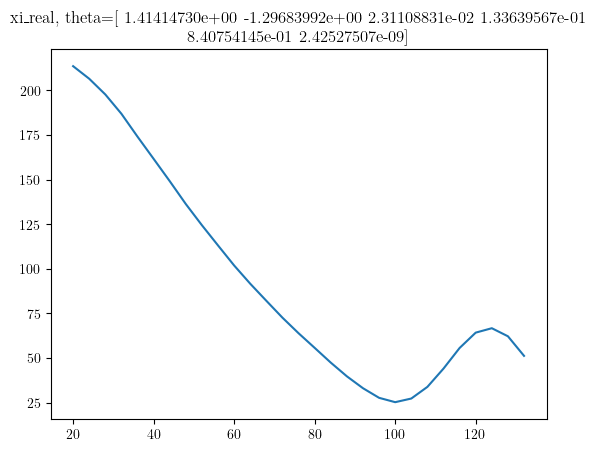

sigma_v0, A_rho0, A_rho_p, sigma_rho, A_Delta, sigma_Delta = [3.47809126e+02 2.74607631e-01 1.01450634e+02 2.88184445e+01
 8.94314515e+01 5.75741623e-01]


In [31]:
from compact.predictions import *
from compact.config import Config

cfg = Config()
csm = CompactStreamingModel(redshift=0.5, config=cfg)

b1, b2, ombh2, omch2, h, As = theta_bad
bias = np.array([b1, b2])
cosmo = (h, ombh2, omch2, As)

csm = CompactStreamingModel(0.5, cfg)

lpt = csm._lpt_inputs(cosmo, bias)
pdf = csm._pdf(lpt, cosmo)

# 1. check xi_real is sane at this cosmology
rs = cfg.r
plt.plot(rs, rs**2 * lpt[0])
plt.title(f'xi_real, theta={theta_bad}')
plt.show()

# 2. check the compact-model params themselves -- this is the new suspect
params = csm._compact_params(cosmo)
print("sigma_v0, A_rho0, A_rho_p, sigma_rho, A_Delta, sigma_Delta =", params)

In [35]:
flagged_idx = flagged   # your list of 42 (or however many) indices

print("Flagged theta ranges (b1, b2, omega_b, omega_cdm, h, As):")
print("  min:", thetas[flagged_idx].min(axis=0))
print("  max:", thetas[flagged_idx].max(axis=0))
print("\nFull sample ranges, for comparison:")
print("  min:", thetas.min(axis=0))
print("  max:", thetas.max(axis=0))

# --- check _compact_params output across the flagged set ---
param_names = ['sigma_v0', 'A_rho0', 'A_rho_p', 'sigma_rho', 'A_Delta', 'sigma_Delta']
all_params = np.zeros((len(flagged_idx), 6))

for i, idx in enumerate(flagged_idx):
    b1, b2, ombh2, omch2, h, As = thetas[idx]
    cosmo = (h, ombh2, omch2, As)
    all_params[i] = csm._compact_params(cosmo)

for j, name in enumerate(param_names):
    print(f"{name:12s}: min={all_params[:, j].min():10.3f}  max={all_params[:, j].max():10.3f}  "
          f"mean={all_params[:, j].mean():10.3f}")

Flagged theta ranges (b1, b2, omega_b, omega_cdm, h, As):
  min: [ 1.48573387e-02 -4.89970606e+00  2.07596439e-02  1.05443400e-01
  5.61347726e-01  1.00162614e-09]
  max: [1.98739732e+00 2.77641115e+00 2.42163769e-02 1.39748588e-01
 8.99958571e-01 5.37642971e-09]

Full sample ranges, for comparison:
  min: [ 2.46211886e-04 -4.99883167e+00  2.07033565e-02  1.04005228e-01
  5.50015770e-01  7.39872094e-10]
  max: [1.99972430e+00 9.99875851e+00 2.42986031e-02 1.39994640e-01
 8.99958571e-01 5.44942897e-09]
sigma_v0    : min=   220.871  max=   462.081  mean=   363.008
A_rho0      : min=     0.239  max=     0.327  mean=     0.291
A_rho_p     : min=    86.985  max=   119.895  mean=   106.728
sigma_rho   : min=    24.162  max=    35.277  mean=    30.779
A_Delta     : min=    28.914  max=   143.911  mean=    96.678
sigma_Delta : min=     0.428  max=     0.876  mean=     0.641


b1=0.0282, b2=1.7438, omega_b=0.0236, omega_cdm=0.1276, h=0.8263, As=3.635e-09
xi_int min: 0.0005582488874620276 at r = 132.0


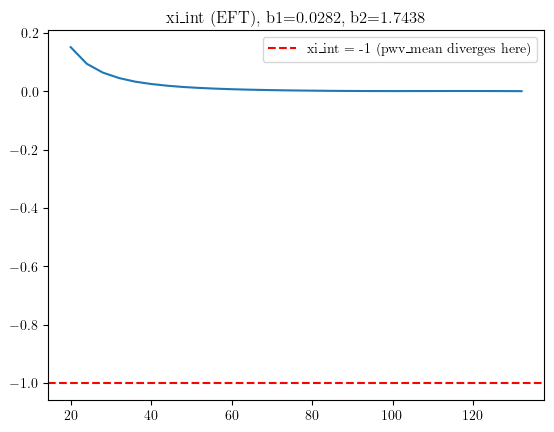

In [41]:
bad_idx = flagged[-1]   # or flagged[1], flagged[2], ... -- pick one from your actual 42
b1, b2, ombh2, omch2, h, As = thetas[bad_idx]
print(f"b1={b1:.4f}, b2={b2:.4f}, omega_b={ombh2:.4f}, omega_cdm={omch2:.4f}, h={h:.4f}, As={As:.3e}")

cosmo = (h, ombh2, omch2, As)
bias = np.array([b1, b2])
lpt_pars = np.concatenate((bias, np.zeros(7)))

gli = GetLPTInputs(csm.z, cosmo, lpt_pars)
gli.get_pklin_gsm()
gli.gsm.compute_cumulants(*lpt_pars)

xi_int_check = np.interp(cfg.r, gli.gsm.rint, gli.gsm.xieft)

plt.plot(cfg.r, xi_int_check)
plt.axhline(-1, c='r', ls='--', label='xi_int = -1 (pwv_mean diverges here)')
plt.legend()
plt.title(f'xi_int (EFT), b1={b1:.4f}, b2={b2:.4f}')

print("xi_int min:", xi_int_check.min(), "at r =", cfg.r[np.argmin(xi_int_check)])

In [42]:
from scipy.integrate import simpson

b1, b2, ombh2, omch2, h, As = thetas[flagged[-1]]
cosmo = (h, ombh2, omch2, As)
bias = np.array([b1, b2])

lpt = csm._lpt_inputs(cosmo, bias)
pdf = csm._pdf(lpt, cosmo)

print("conv:", lpt[-1])
params = csm._compact_params(cosmo)
print("params:", params)

test_points = [(30, 0), (30, 30), (72.5, 20), (100, -50)]

print("\nMpc/h-scale grid (matches simps_integrate's actual convention):")
v_input_grid = np.linspace(-120, 120, 2000)
for r_p, r_los in test_points:
    pv = pdf(v_input_grid, r_p, r_los)
    print(f"  r_p={r_p:6.1f}, r_los={r_los:6.1f}  ->  integral = {simpson(pv, x=v_input_grid):.4f}, "
          f"max|pv|={np.nanmax(np.abs(pv)):.3e}, any NaN: {np.isnan(pv).any()}")

conv: 82.4212289012178
params: [4.05913589e+02 2.95381976e-01 1.09502388e+02 3.14837866e+01
 1.17132746e+02 5.62973504e-01]

Mpc/h-scale grid (matches simps_integrate's actual convention):
  r_p=  30.0, r_los=   0.0  ->  integral = 1.0000, max|pv|=8.956e-02, any NaN: False
  r_p=  30.0, r_los=  30.0  ->  integral = 0.0000, max|pv|=1.902e-318, any NaN: False
  r_p=  72.5, r_los=  20.0  ->  integral = 0.0000, max|pv|=1.420e-314, any NaN: False
  r_p= 100.0, r_los= -50.0  ->  integral = 0.0000, max|pv|=1.593e-315, any NaN: False


In [44]:
import numpy as np

sigma0, A_rho0, A_rho_p, sigma_rho, A_Delta, sigma_Delta = params  # from your printed params
R_PIV = 72.5

for r_p, r_los in [(30, 0), (30, 30), (72.5, 20), (100, -50)]:
    r = np.sqrt(r_p**2 + r_los**2)
    x = r - r_p
    sign_rlos = np.sign(r_los) if r_los != 0 else 1.0

    A_rho = A_rho_mod(r_p, A_rho0, A_rho_p, R_PIV)
    sig_v = sigma_mod(x, sigma0, A_rho, sigma_rho)
    delta_val = delta_mod(x, A_Delta, sigma_Delta) * sign_rlos

    ratio = delta_val / sig_v
    alpha = skew_interp.R_to_alpha(ratio)
    sig_z = skew_interp.alpha_to_sigZ(alpha)
    omega = sig_v / sig_z

    print(f"r_p={r_p:6.1f}, r_los={r_los:6.1f}: x={x:8.3f}  sig_v={sig_v:8.2f}  "
          f"delta_val={delta_val:8.2f}  ratio={ratio:8.3f}  alpha={alpha:8.3f}  "
          f"sig_z={sig_z:8.4f}  omega={omega:10.2f}")

r_p=  30.0, r_los=   0.0: x=   0.000  sig_v=  431.32  delta_val=    0.00  ratio=   0.000  alpha=   0.000  sig_z=  1.2247  omega=    352.17
r_p=  30.0, r_los=  30.0: x=  12.426  sig_v=  482.53  delta_val=  112.06  ratio=   0.232  alpha=  -0.316  sig_z=  1.1930  omega=    404.47
r_p=  72.5, r_los=  20.0: x=   2.708  sig_v=  490.12  delta_val=   96.97  ratio=   0.198  alpha=  -0.268  sig_z=  1.2015  omega=    407.94
r_p= 100.0, r_los= -50.0: x=  11.803  sig_v=  526.77  delta_val= -111.80  ratio=  -0.212  alpha=   0.288  sig_z=  1.1981  omega=    439.68


In [45]:
mean = UnivariateSpline(cfg.r, lpt[1], s=0)

for r_p, r_los in [(30, 0), (30, 30), (72.5, 20), (100, -50)]:
    r = np.sqrt(r_p**2 + r_los**2)
    mu = mean(r) * r_los / r
    print(f"r_p={r_p:6.1f}, r_los={r_los:6.1f}: r={r:8.2f}  mean_vr(r)={mean(r):10.2f}  mu={mu:10.2f}")

r_p=  30.0, r_los=   0.0: r=   30.00  mean_vr(r)=-108381253156394661955163832847429030018742747136.00  mu=     -0.00
r_p=  30.0, r_los=  30.0: r=   42.43  mean_vr(r)=-2111309858221948778727710471344396676069597380608.00  mu=-1492921517934748286180087697959387327041890156544.00
r_p=  72.5, r_los=  20.0: r=   75.21  mean_vr(r)=1890510444819371802232664307182080311519061475328.00  mu=502741548537201496507555956421614851922398806016.00
r_p= 100.0, r_los= -50.0: r=  111.80  mean_vr(r)=1643251732903636713705587527439698982937892487168.00  mu=-734884515783371962637181299051879355693079199744.00


In [46]:
print("veft range:", gli.gsm.veft.min(), gli.gsm.veft.max())
print("xieft range:", gli.gsm.xieft.min(), gli.gsm.xieft.max())

# raw lpt[1] (pwv_mean output before your UnivariateSpline wraps it)
print("\nlpt[1] (pwv_mean) range:", lpt[1].min(), lpt[1].max())
print("lpt[1] at r=30-ish:", np.interp(30, cfg.r, lpt[1]))

veft range: -8.729805384014228e+57 9.932472234826688e+57
xieft range: -0.0004775649008674907 585.5040828534334

lpt[1] (pwv_mean) range: -5.061301052676816e+48 6.397636128278425e+48
lpt[1] at r=30-ish: -1.9289285227834524e+47


In [47]:
print("b1 values across all 42 flagged samples:")
print(np.sort(thetas[flagged, 0]))

b1 values across all 42 flagged samples:
[0.01485734 0.0282486  0.06149733 0.07283453 0.07635834 0.07936435
 0.22792633 0.26921668 0.38176993 0.51719404 0.58651453 0.62547935
 0.67353172 0.70100583 0.7056903  0.73413247 0.74619908 0.78013579
 0.82093804 0.9400206  0.96924147 0.97279771 1.0766127  1.14706952
 1.22163917 1.25805339 1.31795868 1.40379377 1.4141473  1.43692031
 1.44825763 1.4527657  1.50980377 1.65227902 1.66265514 1.8822796
 1.89520165 1.90798036 1.96644471 1.98088184 1.98739732]


In [48]:
print("b2 values across all 42 flagged samples:")
print(np.sort(thetas[flagged, 1]))

print("\nFull-sample b2 range for comparison:", thetas[:,1].min(), thetas[:,1].max())

# check correlation more rigorously: does b1 or b2 (or their ratio/product) separate flagged vs not?
import numpy as np
is_flagged = np.zeros(len(thetas), dtype=bool)
is_flagged[flagged] = True

for name, col in [('b1', thetas[:,0]), ('b2', thetas[:,1]), ('b2/b1', thetas[:,1]/thetas[:,0])]:
    print(f"\n{name}: flagged mean={col[is_flagged].mean():.3f}, "
          f"not-flagged mean={col[~is_flagged].mean():.3f}, "
          f"flagged std={col[is_flagged].std():.3f}, not-flagged std={col[~is_flagged].std():.3f}")

b2 values across all 42 flagged samples:
[-4.89970606 -4.28913078 -4.12272054 -3.82431421 -3.51332792 -3.50419694
 -2.91232784 -2.73292198 -2.52125163 -2.2723982  -2.23185225 -2.14210541
 -2.00632085 -1.96421814 -1.7928206  -1.77384319 -1.59344759 -1.37212652
 -1.29683992 -1.00883873 -0.86014269 -0.70380342 -0.59432048 -0.58636894
 -0.55221719 -0.53915789 -0.42222453 -0.31064493 -0.21106155  0.06519733
  0.08528703  0.42520028  0.83770229  0.8997272   1.01716169  1.34741003
  1.74376704  1.78586921  2.31757518  2.39649618  2.77641115]

Full-sample b2 range for comparison: -4.998831674456596 9.998758514411747

b1: flagged mean=0.990, not-flagged mean=1.000, flagged std=0.615, not-flagged std=0.576

b2: flagged mean=-0.997, not-flagged mean=2.646, flagged std=1.905, not-flagged std=4.342

b2/b1: flagged mean=0.089, not-flagged mean=34.577, flagged std=13.254, not-flagged std=829.249


Text(0.5, 0, 'b2')

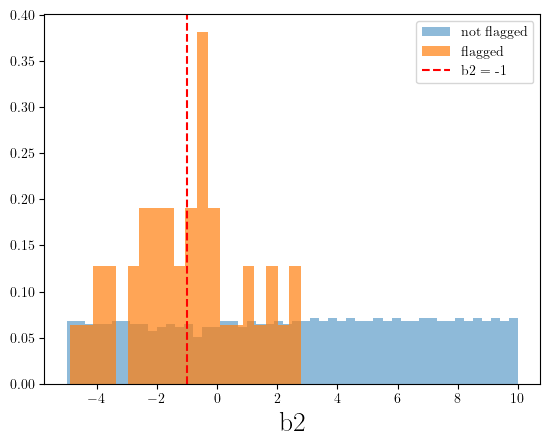

In [49]:
import matplotlib.pyplot as plt

plt.hist(thetas[~is_flagged, 1], bins=50, alpha=0.5, label='not flagged', density=True)
plt.hist(thetas[is_flagged, 1], bins=20, alpha=0.7, label='flagged', density=True)
plt.axvline(-1.0, c='r', ls='--', label='b2 = -1')
plt.legend()
plt.xlabel('b2')

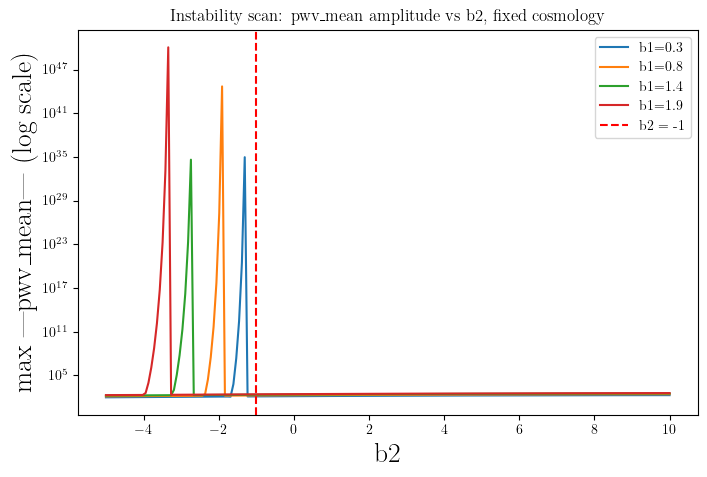

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# fiducial AbacusSummit cosmology, from earlier
cosmo_fid = (0.6736, 0.02237, 0.1200, 2.0830e-9)

b1_values = [0.3, 0.8, 1.4, 1.9]      # representative b1 slice
b2_scan = np.linspace(-5, 10, 200)

fig, ax = plt.subplots(figsize=(8, 5))
for b1_val in b1_values:
    max_abs_veft = np.zeros_like(b2_scan)
    for i, b2_val in enumerate(b2_scan):
        bias = np.array([b1_val, b2_val])
        lpt = csm._lpt_inputs(cosmo_fid, bias)
        max_abs_veft[i] = np.nanmax(np.abs(lpt[1]))   # lpt[1] = pwv_mean output

    ax.semilogy(b2_scan, max_abs_veft, label=f'b1={b1_val}')

ax.axvline(-1, c='r', ls='--', label='b2 = -1')
ax.set_xlabel('b2')
ax.set_ylabel('max |pwv_mean| (log scale)')
ax.legend()
ax.set_title('Instability scan: pwv_mean amplitude vs b2, fixed cosmology')
plt.show()

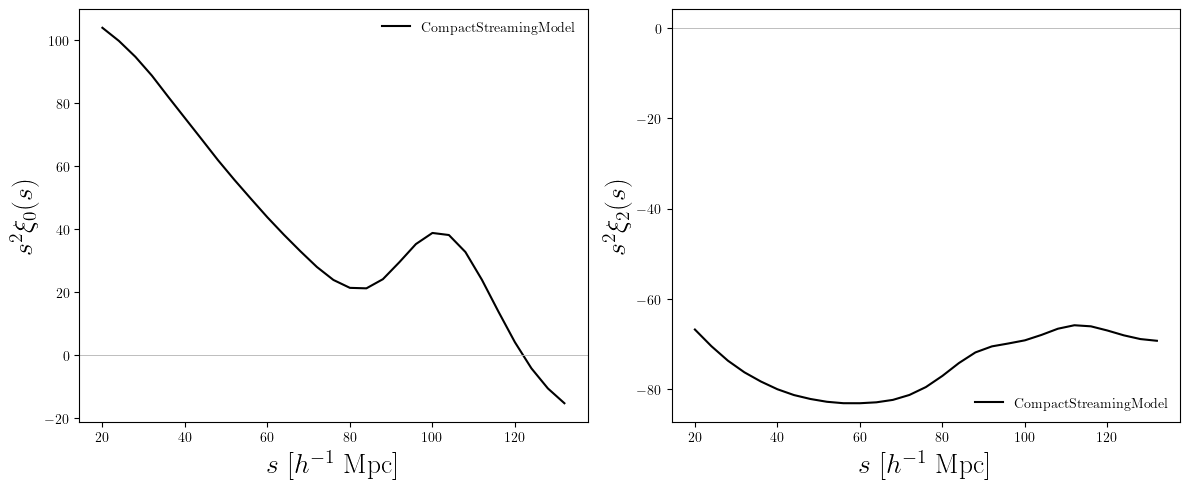

In [53]:
theta_sensible = [1.0, 0.0, 0.02237, 0.1200, 0.6736, 2.0830e-9]   # b1, b2, ombh2, omch2, h, As
mono, quad = csm.predict(theta_sensible, ells=(0, 2))

# s_lrg1, poles_lrg1 = load_poles('LRG', 'dark', 0.4, 0.6)
# mean_lrg1, err_lrg1 = jackknife(poles_lrg1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ax[0].errorbar(s_lrg1, s_lrg1**2 * mean_lrg1[0], s_lrg1**2 * err_lrg1[0],
#                color='#F5A623', marker='o', ms=4, lw=1.2, capsize=2, label='LRG1 mock')
ax[0].plot(cfg.r, cfg.r**2 * mono, 'k-', lw=1.5, label='CompactStreamingModel')
ax[0].axhline(0, color='0.7', lw=0.6)
ax[0].set_xlabel(r'$s$ [$h^{-1}$ Mpc]')
ax[0].set_ylabel(r'$s^2\xi_0(s)$')
ax[0].legend(frameon=False)

# ax[1].errorbar(s_lrg1, s_lrg1**2 * mean_lrg1[1], s_lrg1**2 * err_lrg1[1],
#                color='#F5A623', marker='o', ms=4, lw=1.2, capsize=2, mfc='white', ls='--', label='LRG1 mock')
ax[1].plot(cfg.r, cfg.r**2 * quad, 'k-', lw=1.5, label='CompactStreamingModel')
ax[1].axhline(0, color='0.7', lw=0.6)
ax[1].set_xlabel(r'$s$ [$h^{-1}$ Mpc]')
ax[1].set_ylabel(r'$s^2\xi_2(s)$')
ax[1].legend(frameon=False)

fig.tight_layout()

In [19]:
from scipy.spatial import cKDTree

# normalize params to [0,1] per dimension before distance check
lo, hi = thetas.min(axis=0), thetas.max(axis=0)
theta_norm = (thetas - lo) / (hi - lo)

tree = cKDTree(theta_norm)
dists, idxs = tree.query(theta_norm, k=2)   # nearest neighbor (k=1 is self)
nn_theta_dist = dists[:, 1]
nn_idx = idxs[:, 1]

nn_xi_dist = np.linalg.norm(mono - mono[nn_idx], axis=1) / np.linalg.norm(mono, axis=1)

plt.scatter(nn_theta_dist, nn_xi_dist, s=5, alpha=0.4)
plt.xlabel('nearest-neighbor distance in normalized theta')
plt.ylabel('relative xi_0 difference')

NameError: name 'model' is not defined

Text(0, 0.5, 'held-out RMS residual, xi_0')

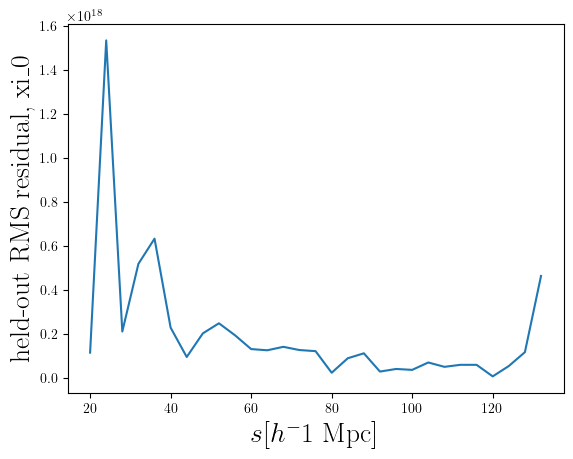

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

train_idx, test_idx = train_test_split(np.arange(len(thetas)), test_size=0.1, random_state=0)

poly = PolynomialFeatures(degree=2)
X_train = poly.fit_transform(thetas[train_idx])
X_test  = poly.transform(thetas[test_idx])

resid_rms = np.zeros(len(cfg.r))
for i_r in range(len(cfg.r)):
    reg = LinearRegression().fit(X_train, mono[train_idx, i_r])
    pred = reg.predict(X_test)
    resid_rms[i_r] = np.sqrt(np.mean((pred - mono[test_idx, i_r])**2))

plt.plot(cfg.r, resid_rms)
plt.xlabel(r'$s [h^-1$ Mpc]'); plt.ylabel('held-out RMS residual, xi_0')